# Day 3: Statistics and Math for Machine Learning  
## NumPy, SciPy, Probability, Regression, and Visual Intuition

This notebook is designed for EEE / engineering students learning machine learning statistics for the first time.

The goal is not to memorize formulas. The goal is to understand how math becomes code and how code becomes visual intuition.

Today we will learn:

- NumPy arrays
- Descriptive statistics
- Probability
- Probability distributions
- Central Limit Theorem
- Hypothesis testing
- A/B testing
- Correlation
- Linear regression
- Regression evaluation
- Sigmoid function

We will use visualizations throughout the notebook so students can see the concepts, not just read formulas.

---
# Slide 1: Setup

## Explanation

Before doing statistics or machine learning, we set up the mathematical environment.

### What is NumPy?

NumPy is used for arrays and numerical operations. In machine learning, almost everything becomes a numerical array:

- Images become pixel arrays
- Audio becomes signal arrays
- Text becomes embeddings
- Scores become arrays
- Model weights become matrices

### What is SciPy?

SciPy provides scientific computing tools such as probability distributions and statistical tests.

### Why use `np.random.seed(42)`?

Randomness is common in ML. Setting a seed makes the same random numbers appear every time, which is useful for teaching and debugging.

In [1]:
import numpy as np
import scipy.stats as stats
import math
import matplotlib.pyplot as plt

print("Day 3: Statistics and Math Environment Initialized.")
np.random.seed(42)

Day 3: Statistics and Math Environment Initialized.


---
# Slide 2: Descriptive Statistics

## Explanation

Descriptive statistics summarize a dataset.

Imagine 123 students submitted a computer vision assignment. Instead of looking at 123 scores one by one, we summarize the class using:

| Statistic | Meaning |
|---|---|
| Mean | Average value |
| Median | Middle value |
| Variance | How spread out values are |
| Standard deviation | Typical distance from the mean |

Mean tells us the center. Standard deviation tells us the spread.

In [25]:
cv_scores = np.random.normal(loc=88, scale=5, size=123)
cv_scores = np.clip(cv_scores, 0, 98)

print(f"Mean (μ): {np.mean(cv_scores):.1f}")
print(f"Median: {np.median(cv_scores):.2f}")
print(f"Variance (σ²): {np.var(cv_scores):.2f}")
print(f"Standard Deviation (σ): {np.std(cv_scores):.2f}")

Mean (μ): 88.0
Median: 88.30
Variance (σ²): 19.14
Standard Deviation (σ): 4.37


## Visualization: Score Distribution

A histogram shows how many students fall into each score range.

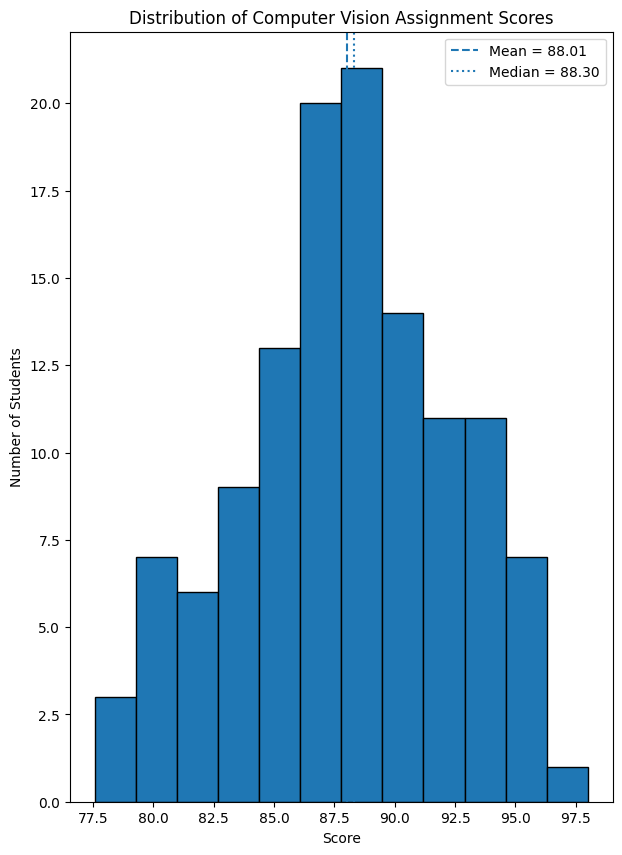

In [28]:
plt.figure(figsize=(7, 10))
plt.hist(cv_scores, bins=12, edgecolor="black")
plt.axvline(np.mean(cv_scores), linestyle="--", label=f"Mean = {np.mean(cv_scores):.2f}")
plt.axvline(np.median(cv_scores), linestyle=":", label=f"Median = {np.median(cv_scores):.2f}")
plt.title("Distribution of Computer Vision Assignment Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.legend()
plt.show()

---
# Slide 3: Probability

## Explanation

Probability measures how likely an event is.

In NLP, probability can answer questions like:

- What is the probability of a word appearing?
- What is the probability of word2 appearing after word1?
- What is the probability that a document belongs to a class?

Simple probability:

```text
P(word) = word count / total tokens
```

Conditional probability:

```text
P(word2 | word1)
```

This means: probability of word2 given that word1 already appeared.

In [4]:
total_tokens = 50000
target_word_count = 1250

probability_word = target_word_count / total_tokens
print(f"P(word) = {probability_word:.4f}")

word1_followed_by_word2 = 800
p_word2_given_word1 = word1_followed_by_word2 / target_word_count
print(f"P(word2 | word1) = {p_word2_given_word1:.4f}")

P(word) = 0.0250
P(word2 | word1) = 0.6400


## Visualization: Target Word Compared to Total Corpus

This bar chart helps students see why the probability is small.

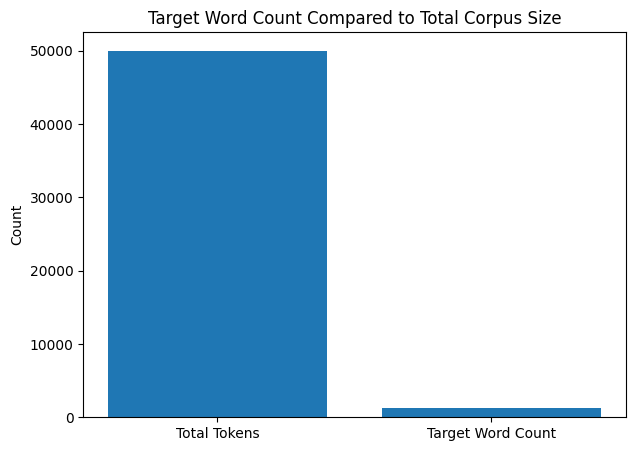

In [5]:
labels = ["Total Tokens", "Target Word Count"]
values = [total_tokens, target_word_count]

plt.figure(figsize=(7, 5))
plt.bar(labels, values)
plt.title("Target Word Count Compared to Total Corpus Size")
plt.ylabel("Count")
plt.show()

---
# Slide 4: Probability Distributions

## Explanation

A probability distribution shows how values are spread.

In machine learning, distributions appear in:

- Scores
- Errors
- Sensor noise
- Pixel intensities
- Model weights
- Prediction probabilities

Here we simulate bonus assignment scores using a normal distribution.

A normal distribution is controlled by:

| Parameter | Meaning |
|---|---|
| `mu` | Mean / center |
| `sigma` | Standard deviation / spread |

In [6]:
mu_bonus = 120
sigma_bonus = 15
bonus_distribution = np.random.normal(mu_bonus, sigma_bonus, 1000)

high_achievers = np.sum(bonus_distribution >= 140)
print(f"Out of 1000 simulated students, {high_achievers} scored 140 or higher.")

Out of 1000 simulated students, 101 scored 140 or higher.


## Visualization: Normal Distribution of Bonus Scores

The dashed line marks the high-achiever threshold.

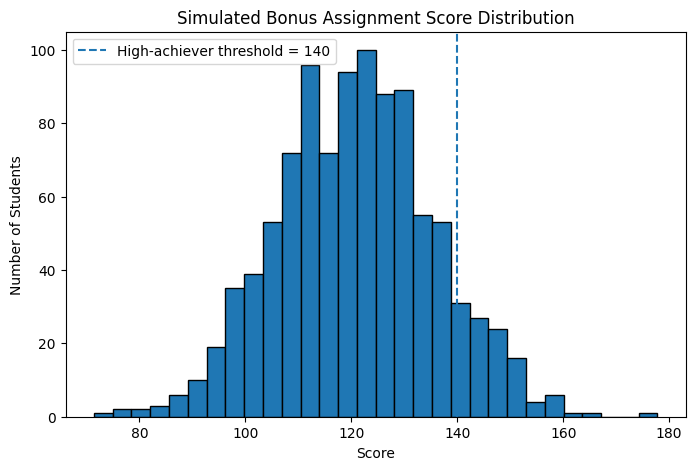

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(bonus_distribution, bins=30, edgecolor="black")
plt.axvline(140, linestyle="--", label="High-achiever threshold = 140")
plt.title("Simulated Bonus Assignment Score Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.legend()
plt.show()

---
# Slide 5: Inferential Statistics and Central Limit Theorem

## Explanation

Inferential statistics helps us make conclusions about a large population using smaller samples.

In ML, we rarely observe everything. We use samples.

### Central Limit Theorem

Even if the original population is not normally distributed, the distribution of sample means becomes approximately normal when sample size is large enough.

This is one of the most important ideas in statistics.

In [8]:
population_data = np.random.uniform(0, 100, 10000)
sample_means = []

for _ in range(500):
    sample = np.random.choice(population_data, 30)
    sample_means.append(np.mean(sample))

print(f"Mean of Population: {np.mean(population_data):.2f}")
print(f"Mean of Sample Means: {np.mean(sample_means):.2f}")

Mean of Population: 49.56
Mean of Sample Means: 49.30


## Visualization: Population vs Sample Means

The original population is uniform, but the sample means become bell-shaped.

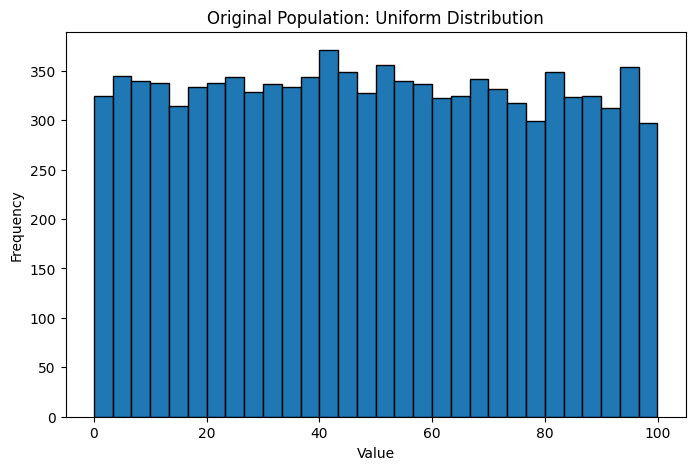

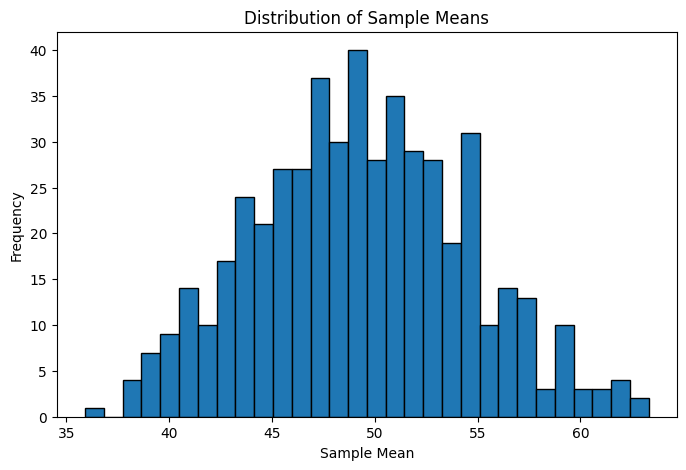

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(population_data, bins=30, edgecolor="black")
plt.title("Original Population: Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=30, edgecolor="black")
plt.title("Distribution of Sample Means")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

---
# Slide 6: Hypothesis Testing Basics

## Explanation

Hypothesis testing helps us decide whether an observed result is meaningful or could have happened by chance.

Here we test whether the average score is significantly different from 85.

Null hypothesis:

```text
H0: The mean score is 85
```

Alternative hypothesis:

```text
HA: The mean score is different from 85
```

A common threshold is `p < 0.05`. If the p-value is less than 0.05, we reject the null hypothesis.

In [10]:
sample_scores = np.random.normal(88, 5, 30)

t_stat, p_value = stats.ttest_1samp(sample_scores, 85.0)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: The score is statistically significantly different from 85.")
else:
    print("Fail to reject H0: No significant difference.")

T-Statistic: 2.2821
P-Value: 0.0300
Reject H0: The score is statistically significantly different from 85.


## Visualization: Sample Scores vs Hypothesized Mean

The dashed line shows the hypothesized mean of 85.

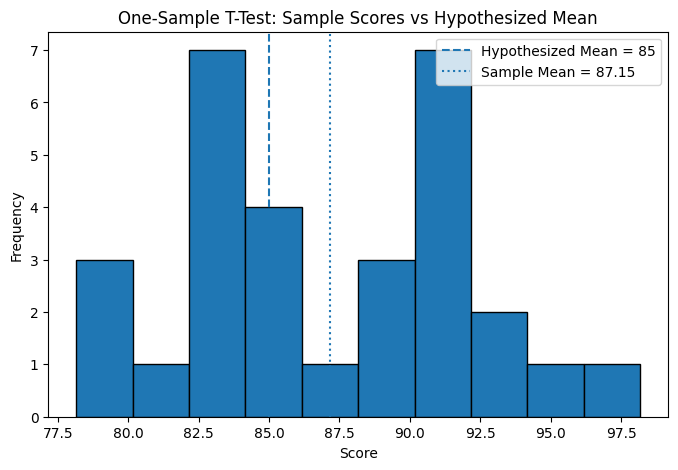

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(sample_scores, bins=10, edgecolor="black")
plt.axvline(85, linestyle="--", label="Hypothesized Mean = 85")
plt.axvline(np.mean(sample_scores), linestyle=":", label=f"Sample Mean = {np.mean(sample_scores):.2f}")
plt.title("One-Sample T-Test: Sample Scores vs Hypothesized Mean")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

---
# Slide 7: A/B Testing

## Explanation

A/B testing compares two versions of something.

In machine learning, we may compare:

- Model A vs Model B
- Old algorithm vs new algorithm
- One preprocessing method vs another
- One recommendation system vs another

If Model B has a higher average accuracy, that does not automatically mean it is truly better. The difference could be due to random variation.

The p-value helps us decide whether the difference is statistically meaningful.

In [12]:
model_a_accuracy = np.random.normal(0.82, 0.02, 50)
model_b_accuracy = np.random.normal(0.85, 0.02, 50)

t_stat, p_val = stats.ttest_ind(model_a_accuracy, model_b_accuracy)

print(f"Model A Mean Accuracy: {np.mean(model_a_accuracy):.4f}")
print(f"Model B Mean Accuracy: {np.mean(model_b_accuracy):.4f}")
print(f"A/B Test P-Value: {p_val:.5f}")

if p_val < 0.05:
    print("The difference is statistically significant.")
else:
    print("The difference is not statistically significant.")

Model A Mean Accuracy: 0.8201
Model B Mean Accuracy: 0.8522
A/B Test P-Value: 0.00000
The difference is statistically significant.


## Visualization: Model A vs Model B

A boxplot helps compare the two model accuracy distributions.

/var/folders/8h/l6ykqqh169n5drt21vy3lkfm0000gn/T/ipykernel_2315/2118319663.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([model_a_accuracy, model_b_accuracy], labels=["Model A", "Model B"])


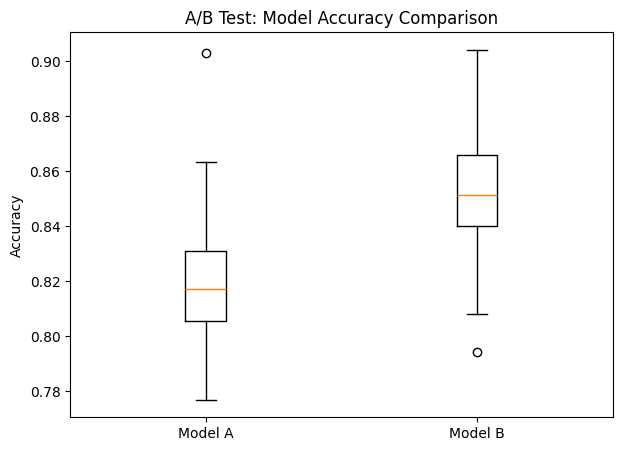

In [13]:
plt.figure(figsize=(7, 5))
plt.boxplot([model_a_accuracy, model_b_accuracy], labels=["Model A", "Model B"])
plt.title("A/B Test: Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

---
# Slide 8: Correlation

## Explanation

Correlation measures how strongly two variables move together.

| r value | Meaning |
|---|---|
| Close to +1 | Strong positive relationship |
| Close to 0 | Little or no linear relationship |
| Close to -1 | Strong negative relationship |

Important warning: correlation does not mean causation.

In [14]:
text_scores = np.random.normal(80, 10, 100)
vision_scores = text_scores + np.random.normal(0, 5, 100)

correlation_matrix = np.corrcoef(text_scores, vision_scores)
r_value = correlation_matrix[0, 1]

print(f"Pearson Correlation (r): {r_value:.4f}")

Pearson Correlation (r): 0.9229


## Visualization: Scatter Plot

If points move upward from left to right, the relationship is positive.

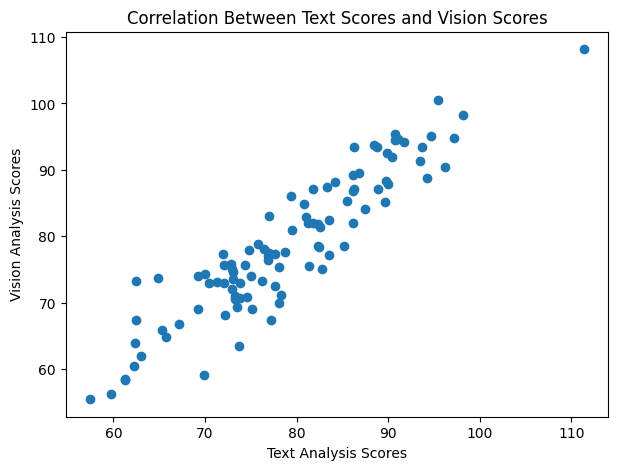

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(text_scores, vision_scores)
plt.title("Correlation Between Text Scores and Vision Scores")
plt.xlabel("Text Analysis Scores")
plt.ylabel("Vision Analysis Scores")
plt.show()

---
# Slide 9: Regression Basics

## Explanation

Regression is used to predict a continuous value.

Examples:

- Predict final score from hours studied
- Predict house price from area
- Predict temperature from sensor readings

In linear regression, we fit a straight line:

```text
y = β0 + β1x
```

`β0` is the intercept and `β1` is the slope.

In [32]:
X = np.array([1, 2, 3, 4, 5])
Y = np.array([50, 60, 75, 85, 95])

print("X values (Independent):", X)
print("Y values (Dependent):", Y)

X values (Independent): [1 2 3 4 5]
Y values (Dependent): [50 60 75 85 95]


## Visualization: Raw Regression Data

The scatter plot shows the relationship before fitting a line.

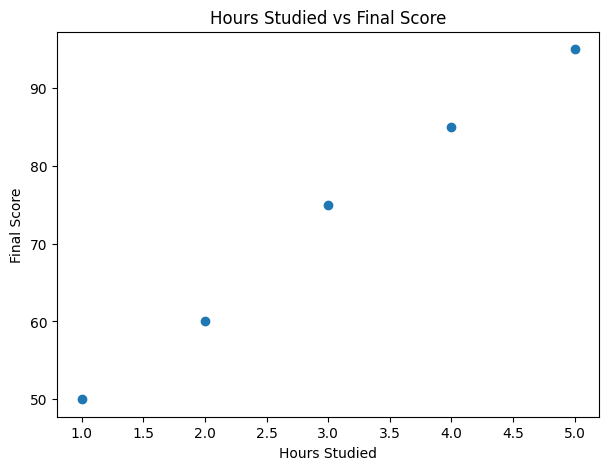

In [33]:
plt.figure(figsize=(7, 5))
plt.scatter(X, Y)
plt.title("Hours Studied vs Final Score")
plt.xlabel("Hours Studied")
plt.ylabel("Final Score")
plt.show()

---
# Slide 10: The Math of Linear Regression

## Explanation

Linear regression finds the best-fitting line.

The slope tells us how much `Y` changes when `X` increases by 1.

This code manually calculates Ordinary Least Squares. OLS chooses the line that minimizes squared prediction errors.

In [18]:
n = len(X)
mean_x, mean_y = np.mean(X), np.mean(Y)

numerator = np.sum((X - mean_x) * (Y - mean_y))
denominator = np.sum((X - mean_x) ** 2)

beta_1 = numerator / denominator
beta_0 = mean_y - (beta_1 * mean_x)

print(f"Equation: y = {beta_0:.2f} + {beta_1:.2f}x")

Equation: y = 38.50 + 11.50x


## Visualization: Best-Fit Line

The line represents the model's predictions.

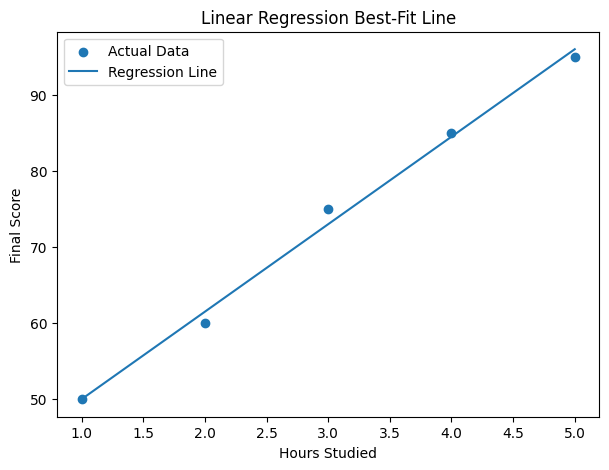

In [ ]:
Y_line = beta_0 + beta_1 * X
plt.figure(figsize=(7, 5))
plt.scatter(X, Y, label="Actual Data")
plt.plot(X, Y_line, label="Regression Line")
plt.title("Linear Regression Best-Fit Line")
plt.xlabel("Hours Studied")
plt.ylabel("Final Score")
plt.legend()
plt.show()

---
# Slide 11: Evaluating Regression

## Explanation

After fitting a regression model, we evaluate it.

### Mean Squared Error

MSE measures average squared prediction error. Lower is better.

### R-squared

R-squared tells us how much variation in `Y` is explained by `X`.

| R² Value | Meaning |
|---|---|
| Close to 1 | Very good fit |
| Close to 0 | Poor fit |
| Negative | Worse than predicting the mean |

In [20]:
Y_pred = beta_0 + beta_1 * X

mse = np.mean((Y - Y_pred) ** 2)
print(f"Mean Squared Error: {mse:.2f}")

ss_total = np.sum((Y - mean_y) ** 2)
ss_residual = np.sum((Y - Y_pred) ** 2)
r2 = 1 - (ss_residual / ss_total)

print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 1.50
R-squared Score: 0.9944


## Visualization: Actual vs Predicted Values

If predicted values are close to actual values, the model is doing well.

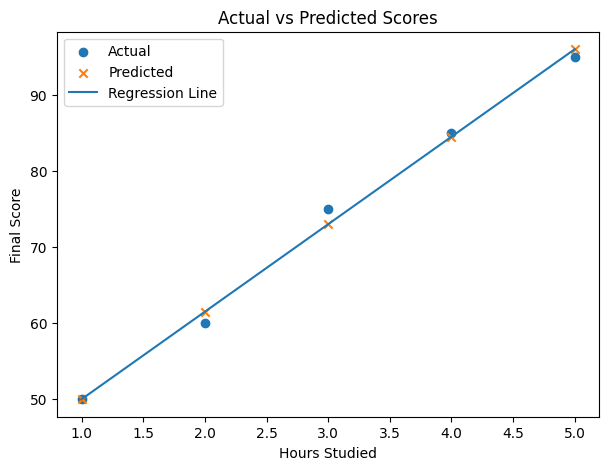

In [21]:
plt.figure(figsize=(7, 5))
plt.scatter(X, Y, label="Actual")
plt.scatter(X, Y_pred, marker="x", label="Predicted")
plt.plot(X, Y_pred, label="Regression Line")
plt.title("Actual vs Predicted Scores")
plt.xlabel("Hours Studied")
plt.ylabel("Final Score")
plt.legend()
plt.show()

---
# Slide 12: Sigmoid Preview

## Explanation

The sigmoid function converts any real number into a value between 0 and 1.

This is useful because many ML models produce raw scores, but we often need probabilities.

Examples:

- Spam probability
- Disease probability
- Fraud probability
- Object detection confidence

```text
sigmoid(z) = 1 / (1 + e^-z)
```

When `z` is 0, sigmoid is 0.5.

In [22]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.array([-5, -1, 0, 1, 5])
probabilities = sigmoid(z_values)

print("Linear Outputs:", z_values)
print("Squashed to Probabilities:", np.round(probabilities, 4))

Linear Outputs: [-5 -1  0  1  5]
Squashed to Probabilities: [0.0067 0.2689 0.5    0.7311 0.9933]


## Visualization: Sigmoid Curve

The sigmoid curve compresses all input values into the range 0 to 1.

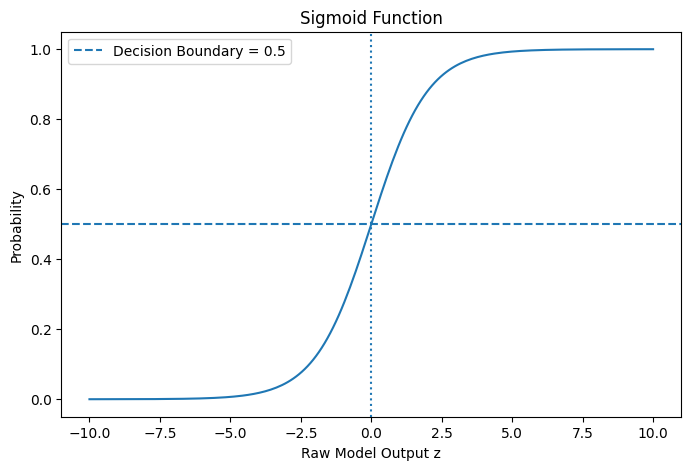

In [23]:
z_curve = np.linspace(-10, 10, 200)
sigmoid_curve = sigmoid(z_curve)

plt.figure(figsize=(8, 5))
plt.plot(z_curve, sigmoid_curve)
plt.axhline(0.5, linestyle="--", label="Decision Boundary = 0.5")
plt.axvline(0, linestyle=":")
plt.title("Sigmoid Function")
plt.xlabel("Raw Model Output z")
plt.ylabel("Probability")
plt.legend()
plt.show()

---
# Extra Mini-Lab: From Raw Score to Decision

## Explanation

In binary classification, we often convert probability into a class label.

Rule:

```text
If probability >= 0.5, predict class 1
Otherwise, predict class 0
```

In [24]:
raw_outputs = np.array([-2.0, -0.5, 0.0, 0.7, 2.5])
probs = sigmoid(raw_outputs)
predictions = probs >= 0.5

for raw, prob, pred in zip(raw_outputs, probs, predictions):
    print(f"Raw Output: {raw:>4} | Probability: {prob:.3f} | Predicted Class: {int(pred)}")

Raw Output: -2.0 | Probability: 0.119 | Predicted Class: 0
Raw Output: -0.5 | Probability: 0.378 | Predicted Class: 0
Raw Output:  0.0 | Probability: 0.500 | Predicted Class: 1
Raw Output:  0.7 | Probability: 0.668 | Predicted Class: 1
Raw Output:  2.5 | Probability: 0.924 | Predicted Class: 1


---
# Day 3 Hands-On Coding Test

The following problems are for students to solve independently.

These are based on Day 3 concepts:

- Descriptive statistics
- Probability
- Hypothesis testing
- Correlation
- Linear regression
- Sigmoid

# Test 1: Easy  
## Descriptive Statistics and Visualization

### Concepts Tested

- NumPy arrays
- Mean
- Median
- Standard deviation
- Histogram

## Problem Statement

You are given the following assignment scores:

```python
scores = np.array([72, 85, 90, 66, 78, 88, 95, 80, 84, 91])
```

Write Python code to:

1. Print the mean score  
2. Print the median score  
3. Print the standard deviation  
4. Create a histogram of the scores  

Use an appropriate title and axis labels for the histogram.

In [ ]:
# Test 1 Student Code

import numpy as np
import matplotlib.pyplot as plt

scores = np.array([72, 85, 90, 66, 78, 88, 95, 80, 84, 91])

# Write your solution here

---
# Test 2: Medium  
## A/B Testing Two Models

### Concepts Tested

- NumPy arrays
- Mean comparison
- Independent t-test
- P-value interpretation

## Problem Statement

Two machine learning models were tested on multiple validation runs.

```python
model_a = np.array([0.81, 0.82, 0.80, 0.83, 0.82, 0.81])
model_b = np.array([0.85, 0.86, 0.84, 0.87, 0.85, 0.86])
```

Write Python code to:

1. Print the mean accuracy of Model A  
2. Print the mean accuracy of Model B  
3. Perform an independent two-sample t-test  
4. Print the p-value  
5. Print whether the difference is statistically significant at `0.05` level.

In [ ]:
# Test 2 Student Code

import numpy as np
import scipy.stats as stats

model_a = np.array([0.81, 0.82, 0.80, 0.83, 0.82, 0.81])
model_b = np.array([0.85, 0.86, 0.84, 0.87, 0.85, 0.86])

# Write your solution here

---
# Test 3: Hard  
## Linear Regression from Scratch

### Concepts Tested

- NumPy arrays
- Mean
- Slope
- Intercept
- Prediction
- MSE
- R-squared
- Regression visualization

## Problem Statement

You are given the following dataset:

```python
hours = np.array([1, 2, 3, 4, 5, 6])
scores = np.array([52, 61, 67, 74, 83, 90])
```

Write Python code to manually calculate linear regression.

Your code should:

1. Calculate the mean of `hours` and `scores`
2. Calculate the slope `beta_1`
3. Calculate the intercept `beta_0`
4. Print the regression equation
5. Predict scores using the regression equation
6. Calculate Mean Squared Error
7. Calculate R-squared
8. Plot the original data points and the regression line

Do not use scikit-learn for this problem.

In [ ]:
# Test 3 Student Code

import numpy as np
import matplotlib.pyplot as plt

hours = np.array([1, 2, 3, 4, 5, 6])
scores = np.array([52, 61, 67, 74, 83, 90])

# Write your solution here

---
# End of Day 3 Notebook

After completing this notebook, students should understand the basic mathematical foundation needed for machine learning:

- NumPy arrays represent data numerically.
- Mean and standard deviation summarize datasets.
- Probability measures uncertainty.
- Distributions describe how values are spread.
- The Central Limit Theorem explains why sample means become normal.
- Hypothesis testing helps decide whether a result is meaningful.
- A/B testing compares two models or systems.
- Correlation measures relationship strength.
- Regression predicts continuous values.
- MSE and R-squared evaluate regression models.
- Sigmoid converts raw scores into probabilities.